In [14]:
import numpy as np

from sklearn.datasets import make_classification
x,y = make_classification(n_features=2 , n_samples=100, n_classes=2, n_informative=2,n_redundant=0, n_clusters_per_class=1,hypercube=False, class_sep=20, random_state=1)

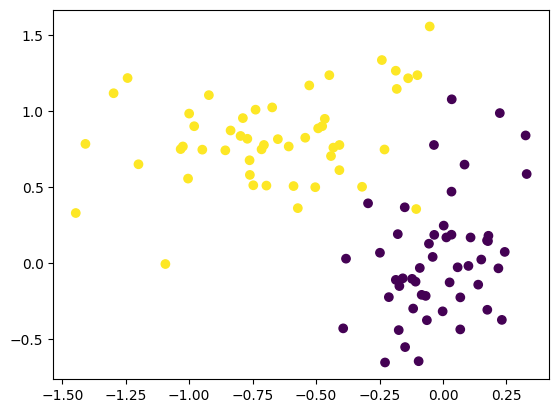

In [15]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

# **Applying Logistic Regression**

In [18]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(x,y)

LogisticRegression()

In [30]:
model_lr.coef_[0]

array([-3.25442838,  2.71511875])

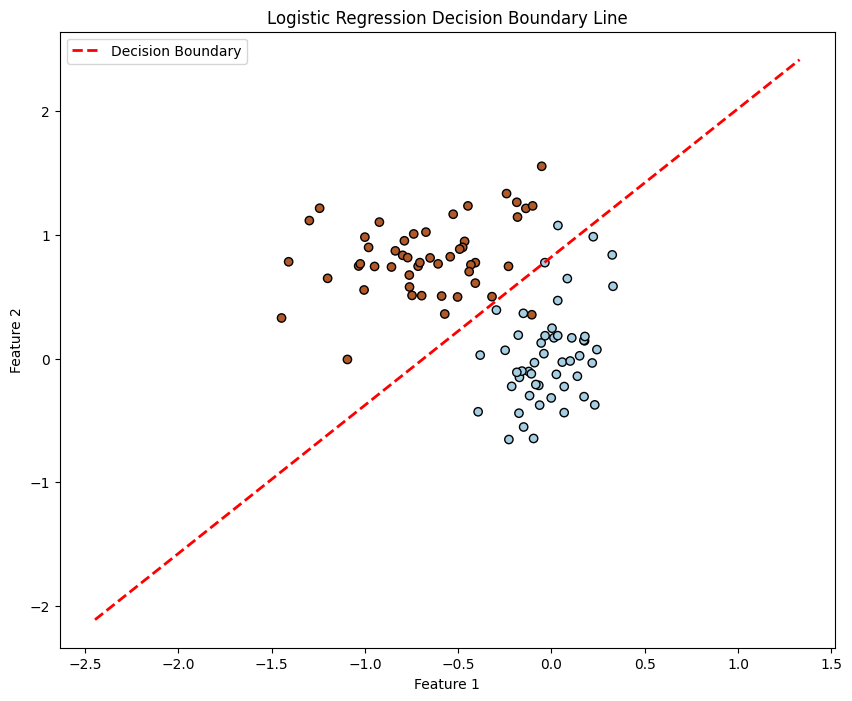

In [26]:
plt.figure(figsize=(10,8))

# Plot the training points
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.Paired, edgecolors='k')

# Create a mesh to plot in
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get the coefficients and intercept from the logistic regression model
coef = model_lr.coef_[0]
intercept = model_lr.intercept_[0]

# Calculate the decision boundary line: w0*x + w1*y + b = 0 => y = (-w0*x - b) / w1
# Avoid division by zero in case w1 is very small or zero
if coef[1] != 0:
    decision_boundary_x = np.array([x_min, x_max])
    decision_boundary_y = (-coef[0] * decision_boundary_x - intercept) / coef[1]
    plt.plot(decision_boundary_x, decision_boundary_y, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
else:
    # If coef[1] is 0, the decision boundary is a vertical line: x = -b / w0
    if coef[0] != 0:
        decision_boundary_x = -intercept / coef[0]
        plt.axvline(x=decision_boundary_x, color='red', linestyle='--', linewidth=2, label='Decision Boundary')


plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary Line')
plt.legend()
plt.show()